# TC4034
## Análisis de grandes volúmenes de datos

<br>

### **Actividad 3 | Aprendizaje supervisado y no supervisado**
<br>

## Profesor Titular
Dr. Iván Olmos Pineda

## Profesor Tutor
Mto. Luis D. Mendoza

## Alumno:
Irving Morales Cedeño -                       A01796208

---

# PARTE 1
Introducción Teórica

---




Aprendizaje Supervisado

- Se entrena un modelo utilizando un conjunto de datos que ya contiene la respuesta correcta.
- Los datos de entrada tienen una etiqueta (label). El algoritmo intenta aprender la relación entre las características (features) y esa etiqueta.
- Durante el entrenamiento, el algoritmo realiza predicciones y las compara con - las etiquetas reales. Utiliza la diferencia (el error) para ajustar los parámetros del modelo hasta que las predicciones sean lo más precisas posible.

Los principales tipos y algoritmos se describen brevemente a continuación (Se agrega al final el comando para ejecutar ese modelo en específico en PySpark):

Clasificación

- Regresión Logística (Logistic Regression): El algoritmo base para clasificación binaria y multinomial. "LogisticRegression()"

- Árboles de Decisión (Decision Trees): Modelos basados en reglas de decisión fáciles de interpretar. "DecisionTreeClassifier()"

- Bosques Aleatorios (Random Forests): Un conjunto de árboles de decisión para mejorar la precisión. "RandomForestClassifier()"

- Árboles con Aumento de Gradiente (Gradient-Boosted Trees - GBT): Algoritmo iterativo potente para clasificación. "GBTClassifier()"

- Perceptrón Multicapa (Multilayer Perceptron): Una red neuronal básica disponible en MLlib. "MultilayerPerceptronClassifier()"

- Máquinas de Soporte Vectorial Lineal (Linear SVC): Utilizado para encontrar el hiperplano óptimo de separación. "LinearSVC()"

- One-vs-Rest (OvR): Técnica para convertir clasificadores binarios en multiclase. "OneVsRest()"

Regresión

- Regresión Lineal (Linear Regression): Para predecir valores continuos. "LinearRegression()"

- Regresión de Árboles de Decisión: Árboles de desición pero para valores continuos. "DecisionTreeRegressor()"

- Random Forest Regressor: Bosques aleatorios pero para valores cotinuos. "RandomForestRegressor()"

- GBT Regressor: Versión de regresión de los árboles con aumento de gradiente. "GBTRegressor()"

- Regresión de Supervivencia AFT (Accelerated Failure Time): Utilizado para modelar el tiempo hasta un evento. "AFTSurvivalRegression()"

- Máquinas de Factorización (FM Regressor): Eficaz para conjuntos de datos con muchas variables categóricas (como sistemas de recomendación). "FMRegressor()"



Aprendizaje No Supervisado

- Se utiliza cuando los datos no tienen etiquetas predefinidas. El objetivo no es predecir un valor específico, sino encontrar una estructura oculta en los datos.
- No hay una "respuesta correcta" ni una columna de etiquetas. El algoritmo explora los datos para encontrar patrones, similitudes o anomalías.
- El algoritmo agrupa los datos que se parecen entre sí o identifica reglas de asociación basadas únicamente en la distribución y las características de los datos de entrada.

Los principales tipos y algoritmos se describen brevemente a continuación (Se agrega al final el comando para ejecutar ese modelo en específico en PySpark):

Agrupamiento (Clustering):

- K-Means: El algoritmo de agrupamiento más común para dividir datos en "k" grupos. "KMeans()"

- Bisecting K-Means: Una variante jerárquica del K-Means (enfoque "top-down"). "BisectingKMeans()"

- Mezcla Gaussiana (Gaussian Mixture - GMM): Modelo probabilístico que asume que los datos provienen de varias distribuciones gaussianas. "GaussianMixture()"

- Asignación Latente de Dirichlet (LDA): Específicamente usado para el modelado de temas (topic modeling) en texto. "LDA()"

- Power Iteration Clustering (PIC): Un algoritmo de clustering espectral escalable. "PowerIterationClustering()"

Minería de Patrones Frecuentes (Frequent Pattern Mining)

- FP-Growth (Frequent Pattern Growth): Utilizado para el análisis de canasta de compras (encontrar artículos que suelen comprarse juntos). "FPGrowth()"

- PrefixSpan: Para la minería de patrones secuenciales (orden de eventos en el tiempo). "PrefixSpan()"

# PARTE 2
Selección de los datos

---




In [ ]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.0/8.3 MB 12.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.9 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 15.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.2 MB 18.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.0/7.2 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 13.7 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   -----

In [ ]:
import os
import sys
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler,StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, DateType
from pyspark.sql.functions import col, when, expr, rand, row_number, concat_ws, year
from pyspark.sql.window import Window

from sklearn.preprocessing import PowerTransformer, MinMaxScaler, OneHotEncoder

In [ ]:
os.environ['HADOOP_HOME'] = "C:/hadoop-3.3.6"
os.environ['PATH'] += os.pathsep + "C:/hadoop-3.3.6/bin"

In [ ]:
#Crear sesión de Spark
spark = SparkSession.builder \
    .appName("AnalisisSteam") \
    .config("spark.driver.memory","4g") \
    .getOrCreate()

print("Sesión de Spark creada con éxito")

Sesión de Spark creada con éxito


## Importar base de datos externa

De acuerdo con la descripción provista en Kaggle, el dataset descargado se conforma por:

1. `games.csv` - Una tabla de información sobre juegos (o extras), calificaciones, precio en doláres USD, fecha de lanzamiento, etc. En el archivo de metados se tienen detalles extra no tabulares, como descripciones y etiquetas

2. `users.csv `- Una tabla con la información pública de los perfiles de usuario, con el número de productos comprados y reseñas publicadas.

3. `recommendations.csv` - Una tabla de reseñas de usuarios (se recomienda o no un producto). Esta tabla representa una relación muchos a muchos (many-many) entre una entidad de juego y una entidad de usuario.

---

In [ ]:
df_rec = spark.read.csv('recommendations.csv',header=True,inferSchema=True)
df_rec.printSchema()

root
 |-- app_id: integer (nullable = true)
 |-- helpful: integer (nullable = true)
 |-- funny: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- is_recommended: boolean (nullable = true)
 |-- hours: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- review_id: integer (nullable = true)



In [ ]:
df_rec.count()

41154794

In [ ]:
df_rec = df_rec.drop("user_id","review_id")

In [ ]:
df_games = spark.read.csv('games.csv',header=True,inferSchema=True)
df_games.printSchema()

root
 |-- app_id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- date_release: date (nullable = true)
 |-- win: boolean (nullable = true)
 |-- mac: boolean (nullable = true)
 |-- linux: boolean (nullable = true)
 |-- rating: string (nullable = true)
 |-- positive_ratio: integer (nullable = true)
 |-- user_reviews: integer (nullable = true)
 |-- price_final: double (nullable = true)
 |-- price_original: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- steam_deck: boolean (nullable = true)



In [ ]:
df_games.count()

50872

In [ ]:
df_games = df_games.select("app_id","title","date_release","rating","price_final")
df_games = df_games.withColumn("Year", year(df_games["date_release"])) #Transformación para tener estadísiticas de la fecha (Año)

In [ ]:
df_games.show()

+------+--------------------+------------+---------------+-----------+----+
|app_id|               title|date_release|         rating|price_final|Year|
+------+--------------------+------------+---------------+-----------+----+
| 13500|Prince of Persia:...|  2008-11-21|  Very Positive|       9.99|2008|
| 22364|BRINK: Agents of ...|  2011-08-03|       Positive|       2.99|2011|
|113020|Monaco: What's Yo...|  2013-04-24|  Very Positive|      14.99|2013|
|226560|  Escape Dead Island|  2014-11-18|          Mixed|      14.99|2014|
|249050|Dungeon of the EN...|  2014-10-27|  Very Positive|      11.99|2014|
|250180|        METAL SLUG 3|  2015-09-14|  Very Positive|       7.99|2015|
|253980|             Enclave|  2013-10-04|Mostly Positive|       4.99|2013|
|271850|Men of War: Assau...|  2014-05-16|          Mixed|       6.99|2014|
|282900|Hyperdimension Ne...|  2015-01-29|  Very Positive|      14.99|2015|
| 19810|The Sum of All Fears|  2008-10-10|Mostly Positive|       9.99|2008|
| 15270|    

In [ ]:
df_final = df_rec.join(df_games, on = "app_id", how = "left") # Realizar JOIN
df_final.show(5)

+-------+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
| app_id|helpful|funny|      date|is_recommended|hours|         title|date_release|              rating|price_final|Year|
+-------+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
| 975370|      0|    0|2022-12-12|          true| 36.3|Dwarf Fortress|  2022-12-06|Overwhelmingly Po...|       30.0|2022|
| 304390|      4|    0|2017-02-17|         false| 11.5|    FOR HONOR™|  2017-02-13|               Mixed|       15.0|2017|
|1085660|      2|    0|2019-11-17|          true|336.5|     Destiny 2|  2019-10-01|       Very Positive|        0.0|2019|
| 703080|      0|    0|2022-09-23|          true| 27.4|    Planet Zoo|  2019-11-05|       Very Positive|       45.0|2019|
| 526870|      0|    0|2021-01-10|          true|  7.9|  Satisfactory|  2020-06-08|Overwhelmingly Po...|       30.0|2020|
+-------+-------+-----+-

In [ ]:
df_final = df_final.drop("app_id")
df_final.show(5)

+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
|helpful|funny|      date|is_recommended|hours|         title|date_release|              rating|price_final|Year|
+-------+-----+----------+--------------+-----+--------------+------------+--------------------+-----------+----+
|      0|    0|2022-12-12|          true| 36.3|Dwarf Fortress|  2022-12-06|Overwhelmingly Po...|       30.0|2022|
|      4|    0|2017-02-17|         false| 11.5|    FOR HONOR™|  2017-02-13|               Mixed|       15.0|2017|
|      2|    0|2019-11-17|          true|336.5|     Destiny 2|  2019-10-01|       Very Positive|        0.0|2019|
|      0|    0|2022-09-23|          true| 27.4|    Planet Zoo|  2019-11-05|       Very Positive|       45.0|2019|
|      0|    0|2021-01-10|          true|  7.9|  Satisfactory|  2020-06-08|Overwhelmingly Po...|       30.0|2020|
+-------+-----+----------+--------------+-----+--------------+------------+-------------

## Caracterización de la población

### Estadísticas descriptivas de los datos

Con base en los percentiles, se considera que la mayor parte de las reseñas no ha recibido ni un voto de "útil" o "gracioso". Mientras que parece haber pocas reseñas con gran cantidad de votos, también se observa desigualdad al ver la desviación estándar.

Por otra parte, se aprecia que el usuario típico dedica alrededor de 27 horas de juego, a pesar de que el promedio se eleva a 100 horas a causa de que una pequeña parte de usuarios le dedican más tiempo.

In [ ]:
df_final.summary().show()

+-------+-----------------+------------------+------------------+--------------------+-------------+------------------+------------------+
|summary|          helpful|             funny|             hours|               title|       rating|       price_final|              Year|
+-------+-----------------+------------------+------------------+--------------------+-------------+------------------+------------------+
|  count|         41154794|          41154794|          41154794|            41154794|     41154794|          41154794|          41154794|
|   mean|3.202566850413587|1.0580708531793404|100.60223780003297|  1669869.3771257808|         NULL|18.626926627524824|2016.7838724693895|
| stddev|46.93648570112021|28.670602782601343|176.16754130448936|  3729246.5425609727|         NULL|16.589551869773633|3.8481151694743594|
|    min|                0|                 0|               0.0|! That Bastard Is...|        Mixed|               0.0|              1997|
|    25%|                0|

**Análisis de "is_recomended"**

In [ ]:
stats_recommended = df_final.groupBy("is_recommended")\
              .agg(F.count("*").alias("freq"))\
              .withColumn("percentage",(F.col("freq")/df_final.count())*100)\
              .orderBy(F.col("freq").desc())

stats_recommended.show()

moda = stats_recommended.first()
print(f"La moda es: '{moda['is_recommended']}' con {moda['freq']} apariciones.")

+--------------+--------+------------------+
|is_recommended|    freq|        percentage|
+--------------+--------+------------------+
|          true|35304398| 85.78441189621797|
|         false| 5850396|14.215588103782029|
+--------------+--------+------------------+

La moda es: 'True' con 35304398 apariciones.


**Análisis de "rating"**

In [ ]:
total_registros = df_final.count()

stats_rating = df_final.groupBy("rating")\
              .agg(F.count("*").alias("freq"))\
              .withColumn("percentage",(F.col("freq")/df_final.count())*100)\
              .orderBy(F.col("freq").desc())

stats_rating.show()

moda = stats_rating.first()
print(f"La moda es: '{moda['rating']}' con {moda['freq']} apariciones.")

+--------------------+--------+--------------------+
|              rating|    freq|          percentage|
+--------------------+--------+--------------------+
|       Very Positive|23470702|   57.03029882739785|
|Overwhelmingly Po...| 9722041|  23.623106945936843|
|     Mostly Positive| 4580710|  11.130440842444747|
|               Mixed| 3029850|   7.362082774609442|
|     Mostly Negative|  193331|  0.4697654421499473|
|            Positive|  133560|  0.3245308432354199|
|Overwhelmingly Ne...|   17167| 0.04171324487737686|
|            Negative|    4686|0.011386279809832119|
|       Very Negative|    2747|0.006674799538542217|
+--------------------+--------+--------------------+

La moda es: 'Very Positive' con 23470702 apariciones.


### Manejo de outliers

Se aprecia que existen valores extremos en las variables `helpful` (reseñas con más de 36,000 votos) y `hours` (usuarios con 1000 horas jugadas), y, por el momento, se optó por conservarlos. Esto debido a que permiten observar el comportamiento real de los usuarios (por ejemplo, de influencer o gamers hardcore ).

## Implementación de la etapa de particionamiento


In [ ]:
# 1. Ingeniería de Características: Clasificar los datos según los umbrales definidos
df_categorizado = df_final.withColumn(
    "categoria_epoca",
    when(col("date_release") < "2018-01-01", "Clasico").otherwise("Nuevo")
).withColumn(
    "categoria_precio",
    when(col("price_final") < 15.0, "Barato").otherwise("Caro")
).withColumn(
    "clasificacion",
    when(col("rating").contains("Negative"), "Negativo")
    .when(col("rating").contains("Positive"), "Positivo")
    .otherwise("Mixto")
)

# 2. Crear la llave de estrato (Segmento)
df_estratos = df_categorizado.withColumn(
    "perfil_juego",
    expr("concat_ws('_', categoria_epoca, clasificacion, categoria_precio)")
)


In [ ]:
# Muestra hasta 100 estratos (o los que haya)
df_estratos.select("perfil_juego").distinct().show(n=100, truncate=False)

+-----------------------+
|perfil_juego           |
+-----------------------+
|Nuevo_Mixto_Barato     |
|Nuevo_Positivo_Barato  |
|Nuevo_Positivo_Caro    |
|Nuevo_Mixto_Caro       |
|Clasico_Positivo_Barato|
|Clasico_Mixto_Barato   |
|Clasico_Positivo_Caro  |
|Clasico_Mixto_Caro     |
|Nuevo_Negativo_Barato  |
|Clasico_Negativo_Caro  |
|Nuevo_Negativo_Caro    |
|Clasico_Negativo_Barato|
+-----------------------+



In [ ]:
total_estratos = df_estratos.select("perfil_juego").distinct().count()
print(f"Total de estratos únicos: {total_estratos}")

Total de estratos únicos: 12


In [ ]:
df_proporciones = df_estratos.groupBy("perfil_juego").count()

total_registros = df_estratos.count()

df_proporciones = df_proporciones.withColumn(
    "proporcion",
    F.col("count") / total_registros
).withColumn(
    "porcentaje",
    F.concat(F.round(F.col("proporcion") * 100, 2), F.lit("%"))
)

df_proporciones.orderBy(F.col("proporcion").desc()).show()

+--------------------+--------+--------------------+----------+
|        perfil_juego|   count|          proporcion|porcentaje|
+--------------------+--------+--------------------+----------+
|Clasico_Positivo_...|10809875|  0.2626638101991228|    26.27%|
| Nuevo_Positivo_Caro|10708069|  0.2601900765193965|    26.02%|
|Clasico_Positivo_...| 9493526| 0.23067849641040603|    23.07%|
|Nuevo_Positivo_Ba...| 6895543|  0.1675513914612232|    16.76%|
|Clasico_Mixto_Barato|  918286| 0.02231297768128787|     2.23%|
|    Nuevo_Mixto_Caro|  901004| 0.02189305090434908|     2.19%|
|  Nuevo_Mixto_Barato|  841708|0.020452246705450646|     2.05%|
|  Clasico_Mixto_Caro|  368852| 0.00896255245500682|      0.9%|
|Nuevo_Negativo_Ba...|  115166|0.002798361716984...|     0.28%|
|Clasico_Negativo_...|   74341|0.001806375218401...|     0.18%|
| Nuevo_Negativo_Caro|   19758|  4.8008987725707E-4|     0.05%|
|Clasico_Negativo_...|    8666|2.105708511139674...|     0.02%|
+--------------------+--------+---------

Se tiene una población de 41,154,794 por lo que se considerará el tamaño de muestra de acuerdo con la fórmula Cochran para poblaciones infinitas. Para este caso se tiene:

* Z = 2.576 (Nivel de confianza 99%)
* p = 0.5 (Para obtener una muestra significativa se toma 50%, más considerando que el objetivo es crear un sistema de recomendación)
* e = 0.01

$$n = \frac{(2.576)^2 \cdot 0.5 \cdot 0.5}{(0.01)^2}$$$$n = \frac{6.635776 \cdot 0.25}{0.0001}$$$$n = \frac{1.658944}{0.0001} = \mathbf{16,590}$$

Entonces el tamaño de la muestra sería de 16,590. Dicha población se distribuirá de acuerdo con los porcentajes que corresponden a cada estrato. Sin embargo, considerando que se tienen algunos estratos muy poco representados, se aumentará arbitrariamente para asumir que todas las categorías deben tener como mínimo 100 elementos, aunque esto afecte la proporción original de los datos, dado que la idea es entrenar un algoritmo de ML y si se tienen estratos poco representados pueden surgir recomendaciones erradas.

In [ ]:
TOTAL_MUESTRA_OBJETIVO = 16590
PISO_MINIMO = 100

total_poblacion = df_estratos.count()

df_cuotas = df_estratos.groupBy("perfil_juego").count() \
    .withColumn(
        "cuota_proporcional",
        F.round((F.col("count") / total_poblacion) * TOTAL_MUESTRA_OBJETIVO).cast("int")
    ) \
    .withColumn(
        "cuota_estrato",
        F.greatest(F.col("cuota_proporcional"), F.lit(PISO_MINIMO))
    ) \
    .select("perfil_juego", "cuota_estrato")

df_con_cuotas = df_estratos.join(df_cuotas, "perfil_juego")

window_spec = Window.partitionBy("perfil_juego").orderBy(F.rand())

df_muestra = df_con_cuotas \
    .withColumn("row_num", F.row_number().over(window_spec)) \
    .filter(F.col("row_num") <= F.col("cuota_estrato")) \
    .drop("row_num", "cuota_estrato")

# Verificar los resultados
df_muestra.groupBy("perfil_juego").count().show()
print(f"Total de la muestra: {df_muestra.count()}")

+--------------------+-----+
|        perfil_juego|count|
+--------------------+-----+
|Clasico_Negativo_...|  100|
|  Nuevo_Mixto_Barato|  339|
|Nuevo_Negativo_Ba...|  100|
| Nuevo_Negativo_Caro|  100|
|Nuevo_Positivo_Ba...| 2780|
|Clasico_Negativo_...|  100|
|    Nuevo_Mixto_Caro|  363|
| Nuevo_Positivo_Caro| 4317|
|Clasico_Positivo_...| 4358|
|Clasico_Mixto_Barato|  370|
|  Clasico_Mixto_Caro|  149|
|Clasico_Positivo_...| 3827|
+--------------------+-----+

Total de la muestra: 16903


In [ ]:
M_df_o = df_muestra.drop('helpful','funny','date', 'title','date_release','categoria_epoca','rating','categoria_precio')
M_df_o.show()

In [ ]:
M_df_o.write.mode("overwrite").parquet("m.parquet")

Se guarda el dataframe preprocesado para su uso posterior

# PARTE 3
Preparación de los datos

---

In [ ]:
M_df = spark.read.parquet("m.parquet")
M_df.show()

+--------------------+--------------+-----+-----------+----+-------------+
|        perfil_juego|is_recommended|hours|price_final|Year|clasificacion|
+--------------------+--------------+-----+-----------+----+-------------+
|Clasico_Positivo_...|          true|  6.7|       10.0|2009|     Positivo|
|Clasico_Positivo_...|          true|  7.8|       7.49|2017|     Positivo|
|Clasico_Positivo_...|          true|270.7|       9.99|2012|     Positivo|
|Clasico_Positivo_...|          true| 65.4|       10.0|2010|     Positivo|
|Clasico_Positivo_...|          true|  5.6|       9.99|2012|     Positivo|
|Clasico_Positivo_...|         false| 32.4|      14.99|2016|     Positivo|
|Clasico_Positivo_...|          true|  5.2|       10.0|2013|     Positivo|
|Clasico_Positivo_...|          true|  1.3|       2.59|2016|     Positivo|
|Clasico_Positivo_...|          true|109.8|        0.0|2017|     Positivo|
|Clasico_Positivo_...|          true| 11.0|      14.99|2017|     Positivo|
|Clasico_Positivo_...|   

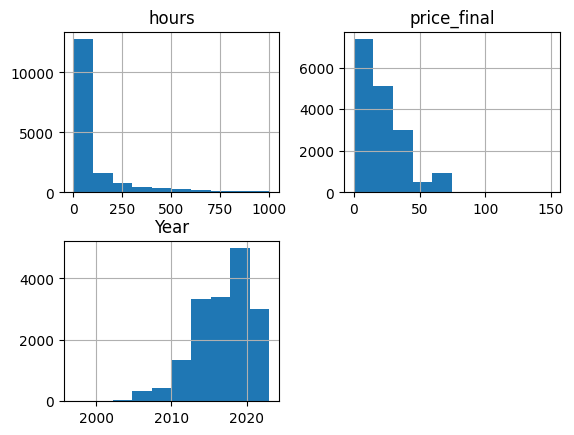

In [ ]:
M_pd = M_df.toPandas()
M_pd.hist()
plt.show()

Se observa que las 3 variables están sesgadas por lo que se procede con una transformaciópn Yeo-Johnson/Box-Cox para centrarlas

/usr/local/lib/python3.12/dist-packages/scipy/stats/_morestats.py:1186: UserWarning: The optimal lambda is 161.93671648356764, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


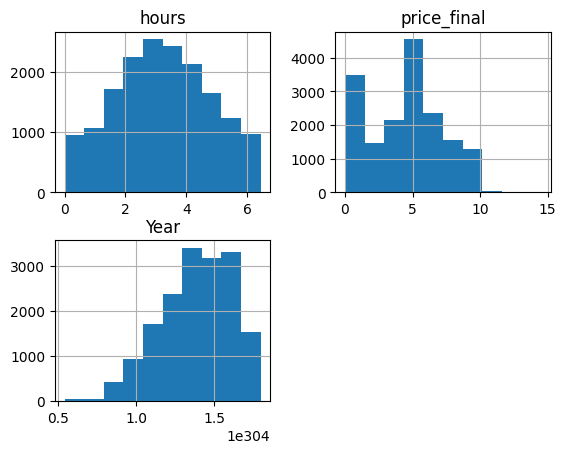

In [ ]:
transformer = PowerTransformer(method='yeo-johnson', standardize=False)
transf = transformer.fit_transform(M_pd[['hours','price_final']])
transf_df1 = pd.DataFrame(transf, columns=transformer.get_feature_names_out())

transformer = PowerTransformer(method='box-cox', standardize=False)
transf = transformer.fit_transform(M_pd[['Year']])
transf_df2 = pd.DataFrame(transf, columns=transformer.get_feature_names_out())

transf_df = pd.concat([transf_df1, transf_df2], axis=1)
transf_df.hist()
plt.show()

Como las 3 variables tienen diferentes escalas se procede a unificarlas con MinMax scaler

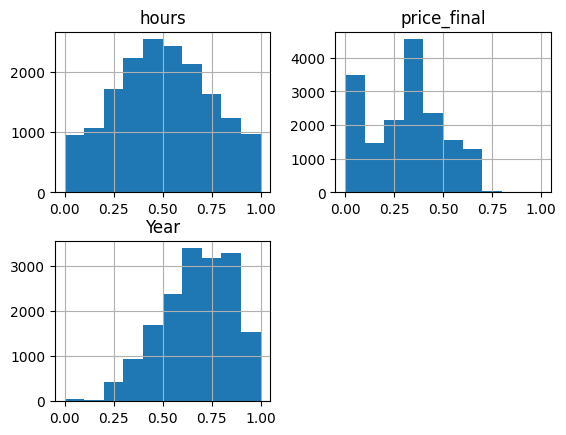

In [ ]:
scaler = MinMaxScaler()
minmax = scaler.fit_transform(transf_df)
minmax_df = pd.DataFrame(minmax, columns=scaler.get_feature_names_out())
minmax_df.hist()
plt.show()

Habiendo terminando el análisis de las variables numéricas se procede a crear un nuevo dataframe

In [ ]:
M_temp_pd = pd.concat([minmax_df, M_pd[['clasificacion','is_recommended','perfil_juego']]], axis=1)
M_temp_pd

,hours,price_final,Year,clasificacion,is_recommended,perfil_juego
0,0.310232,0.265664,0.320571,Positivo,True,Clasico_Positivo_Barato
1,0.330081,0.224421,0.655534,Positivo,True,Clasico_Positivo_Barato
2,0.821865,0.265512,0.432140,Positivo,True,Clasico_Positivo_Barato
3,0.623990,0.265664,0.356079,Positivo,True,Clasico_Positivo_Barato
4,0.287251,0.265512,0.432140,Positivo,True,Clasico_Positivo_Barato
...,...,...,...,...,...,...
16898,0.128147,0.476323,0.606702,Mixto,False,Clasico_Mixto_Caro
16899,0.168572,0.476323,0.560040,Mixto,True,Clasico_Mixto_Caro
16900,0.226458,0.332761,0.655534,Mixto,True,Clasico_Mixto_Caro
16901,0.367105,0.387508,0.560040,Mixto,True,Clasico_Mixto_Caro


In [ ]:
M_temp_df = spark.createDataFrame(M_temp_pd)
M_temp_df = M_temp_df.withColumn("is_recommended", col("is_recommended").cast("integer"))

Se modifica el tipo de data de "is_recommend" a integer para que se pueda usar en el modelo de entrenamiento

In [ ]:
M_temp_df.printSchema()

root
 |-- hours: double (nullable = true)
 |-- price_final: double (nullable = true)
 |-- Year: double (nullable = true)
 |-- clasificacion: string (nullable = true)
 |-- is_recommended: integer (nullable = true)
 |-- perfil_juego: string (nullable = true)



Se procede a codificar la variable "clasificacion" para que se pueda usar en el modelo de entrenamiento

In [ ]:
clasificacionEncoder = StringIndexer(inputCol='clasificacion',outputCol='rating')
M_temp_df = clasificacionEncoder.fit(M_temp_df).transform(M_temp_df)
M_temp_df.show()

+-------------------+-------------------+-------------------+-------------+--------------+--------------------+------+
|              hours|        price_final|               Year|clasificacion|is_recommended|        perfil_juego|rating|
+-------------------+-------------------+-------------------+-------------+--------------+--------------------+------+
|0.31023209922847317|0.26566411431629733| 0.3205713024764751|     Positivo|             1|Clasico_Positivo_...|   0.0|
|0.33008095172930213|0.22442080573733264|  0.655533723484915|     Positivo|             1|Clasico_Positivo_...|   0.0|
|  0.821865395367196| 0.2655122789521011|0.43213965971598106|     Positivo|             1|Clasico_Positivo_...|   0.0|
| 0.6239900343932654|0.26566411431629733|0.35607921323190356|     Positivo|             1|Clasico_Positivo_...|   0.0|
|0.28725108231551527| 0.2655122789521011|0.43213965971598106|     Positivo|             1|Clasico_Positivo_...|   0.0|
|  0.525411785428739| 0.3326408782258213|  0.606

Se crea un vector de features con todas las variables para un procesado posterior más rápido

In [ ]:
assembler = VectorAssembler(inputCols=['hours','price_final','Year','rating'],outputCol='features')
M_temp_df = assembler.transform(M_temp_df)
M_df = M_temp_df.select(['features','is_recommended','perfil_juego'])
M_df.show()

+--------------------+--------------+--------------------+
|            features|is_recommended|        perfil_juego|
+--------------------+--------------+--------------------+
|[0.31023209922847...|             1|Clasico_Positivo_...|
|[0.33008095172930...|             1|Clasico_Positivo_...|
|[0.82186539536719...|             1|Clasico_Positivo_...|
|[0.62399003439326...|             1|Clasico_Positivo_...|
|[0.28725108231551...|             1|Clasico_Positivo_...|
|[0.52541178542873...|             0|Clasico_Positivo_...|
|[0.27790987707624...|             1|Clasico_Positivo_...|
|[0.12814742461868...|             1|Clasico_Positivo_...|
|[0.69655511401313...|             1|Clasico_Positivo_...|
|[0.37597643427099...|             1|Clasico_Positivo_...|
|[0.47567437624547...|             0|Clasico_Positivo_...|
|[0.97126028150763...|             1|Clasico_Positivo_...|
|[0.67645883559426...|             1|Clasico_Positivo_...|
|[0.37597643427099...|             1|Clasico_Positivo_..

In [ ]:
M_df.groupBy('is_recommended').count().show()

+--------------+-----+
|is_recommended|count|
+--------------+-----+
|             1|14334|
|             0| 2569|
+--------------+-----+



# PARTE 4
Preparación del conjunto de entrenamiento y prueba

---

Como anteriormente ya se tenian bien identificados los estratos y con ello el comportamiento de la población en general, se usará el método de "Stratified Random Sampling". Es decir, a cada estrato se le extraerá de forma aleatoria un 80% de datos para entrenamiento y un 20% para pruebas, con esto se asegura que cada estrato está debidamente representado

In [ ]:
train_df_1,test_df_1 = M_df.filter(col('perfil_juego') == 'Clasico_Negativo_Barato').randomSplit([0.8,0.2])
train_df_1.count()
test_df_1.count()

19

In [ ]:
train_df_2,test_df_2 = M_df.filter(col('perfil_juego') == 'Nuevo_Mixto_Barato').randomSplit([0.8,0.2])
train_df_2.count()
test_df_2.count()

61

In [ ]:
train_df_3,test_df_3 = M_df.filter(col('perfil_juego') == 'Nuevo_Negativo_Barato').randomSplit([0.8,0.2])
train_df_3.count()
test_df_3.count()

18

In [ ]:
train_df_4,test_df_4 = M_df.filter(col('perfil_juego') == 'Nuevo_Negativo_Caro').randomSplit([0.8,0.2])
train_df_4.count()
test_df_4.count()

15

In [ ]:
train_df_5,test_df_5 = M_df.filter(col('perfil_juego') == 'Nuevo_Positivo_Barato').randomSplit([0.8,0.2])
train_df_5.count()
test_df_5.count()

525

In [ ]:
train_df_6,test_df_6 = M_df.filter(col('perfil_juego') == 'Clasico_Negativo_Caro').randomSplit([0.8,0.2])
train_df_6.count()
test_df_6.count()

22

In [ ]:
train_df_7,test_df_7 = M_df.filter(col('perfil_juego') == 'Nuevo_Mixto_Caro').randomSplit([0.8,0.2])
train_df_7.count()
test_df_7.count()

52

In [ ]:
train_df_8,test_df_8 = M_df.filter(col('perfil_juego') == 'Nuevo_Positivo_Caro').randomSplit([0.8,0.2])
train_df_8.count()
test_df_8.count()

828

In [ ]:
train_df_9,test_df_9 = M_df.filter(col('perfil_juego') == 'Clasico_Positivo_Barato').randomSplit([0.8,0.2])
train_df_9.count()
test_df_9.count()

795

In [ ]:
train_df_10,test_df_10 = M_df.filter(col('perfil_juego') == 'Clasico_Mixto_Barato').randomSplit([0.8,0.2])
train_df_10.count()
test_df_10.count()

74

In [ ]:
train_df_11,test_df_11 = M_df.filter(col('perfil_juego') == 'Clasico_Mixto_Caro').randomSplit([0.8,0.2])
train_df_11.count()
test_df_11.count()

25

In [ ]:
train_df_12,test_df_12 = M_df.filter(col('perfil_juego') == 'Clasico_Positivo_Caro').randomSplit([0.8,0.2])
train_df_12.count()
test_df_1.count()

19

Se procede a unificar los dataframes en uno solo de training y otro de pruebas

In [ ]:
train_df = train_df_1.union(train_df_2).union(train_df_3).union(train_df_4).union(train_df_5).union(train_df_6).union(train_df_7).union(train_df_8).union(train_df_9).union(train_df_10).union(train_df_11).union(train_df_12)
train_df.count()

13681

In [ ]:
test_df = test_df_1.union(test_df_2).union(test_df_3).union(test_df_4).union(test_df_5).union(test_df_6).union(test_df_7).union(test_df_8).union(test_df_9).union(test_df_10).union(test_df_11).union(test_df_12)
test_df.count()

3222

# PARTE 5
Construcción de modelos de aprendizaje supervisado y no supervisado
---

Supervisado: Regresión Logística

Se inicializa el modelo definiendo cual es la variables a predecir "is_recommended" y aqui es donde se usa la columna de "features" previamente creada

In [ ]:
lr = LogisticRegression(featuresCol='features',labelCol='is_recommended')
lr_model = lr.fit(train_df)

Una vez con el modelo entrenado, se calculan las predicciones para ambos conjuntos

In [ ]:
pred_train = lr_model.transform(train_df)
pred_test = lr_model.transform(test_df)

Se evalua el modelo con ambos conjuntos enfocándose en la métrica accuracy

In [ ]:
evaluator = MulticlassClassificationEvaluator(labelCol='is_recommended',metricName='accuracy')
evaluator.evaluate(pred_train)

0.856150866164754

In [ ]:
evaluator.evaluate(pred_test)

0.8699565487274985

Se observa que el accuracy está arriba del 80% en ambos conjuntos por lo que no está subentrenado y la diferencia entre ellos es de menos de 0.01 por lo que no está sobrentrenado.

Se puede concluir entonces que las técnicas de preprocesamiento y división de los conjuntos de entrenamiento y prueba fueron las adecuadas porque el modelo presenta muy buen desempeño

No supervisado: Kmeans - Clustering

Se inicializa el modelo definiendo las variables que se usarán para agrupar (La columna features previamente definida) y se omite la variable de salida pero si se pone el número de clusters, en este caso 2, se recomienda o no el juego.

In [ ]:
kmeans = KMeans(featuresCol='features',k=2)
model = kmeans.fit(train_df)

Con el modelo ya entrenado se calculan las predicciones para ambos conjuntos

In [ ]:
pred_train = model.transform(train_df)
pred_test = model.transform(test_df)

Se evalua el modelo con ambos conjuntos enfocándose en la métrica silhouette (Que determina que tan bien separados y definidos están los clusters)

In [ ]:
evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='features', metricName='silhouette')
evaluator.evaluate(pred_train)

0.851266755894617

In [ ]:
evaluator.evaluate(pred_test)


0.8567231699031933

Se observa que el Coeficiente de silueta es cercano a 1 en ambos conjuntos por lo que no está subentrenado y la diferencia entre ellos es de menos de 0.01 por lo que no está sobrentrenado.

Se esperaba un poco este resultado ya que la regresión logistica se comportó bastante bien. Esto confirman que las técnicas de preprocesamiento y muestreo fueron adecuadas.

Como la métrica está cercana a 1 en ambos conjuntos, se puede concluir que el modelo no supervisado, también tiene muy buen desempeño